## Problem Description

Ice, an online store dedicated to selling video games globally, seeks to identify the factors that determine a title's commercial success. To do this, they have a dataset that includes user and expert reviews, genres, platforms (such as Xbox and PlayStation), ESRB ratings, and historical sales records dating back to 2016.

The challenge is to analyze this data to discover behavioral patterns and key variables that influence a video game's performance in the market. The goal is to generate information that will allow them to identify promising projects and design more effective advertising campaigns.

The analysis is presented in a simulated context: December 2016, with the task of forecasting 2017 sales. However, the project's main value lies in the practical experience of working with data, applicable to any time frame.

The dataset's rating column, which reflects the age classification assigned by the ESRB, adds an additional dimension to the study, allowing for an evaluation of how content restrictions can impact the acceptance and success of video games.

## Data
1. Name	
2. Platform	
3. Year_of_Release	
4. Genre	
5. NA_sales	= North American sales in millions of US dollars
6. EU_sales	= European sales in millions of US dollars
7. JP_sales	= Japan sales in millions of US dollars
8. Other_sales	= Sales in other countries in millions of US dollars
9. Critic_Score = maximum of 100	
10. User_Score	= maximum of 10
11. Rating = ESRB


In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [209]:
# Load the database
data = pd.read_csv('../Datos/games.csv')

In [210]:
#Initial exploratory analysis
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [211]:
data.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [212]:
# step 2. Prepare the data - Data Wrangling
# Standardize column names to lowercase.

data.columns = data.columns.str.lower().str.strip()


In [213]:
# Find duplicate values ​​in 3 columns of the dataframe
data[data.duplicated(['name', 'platform', 'year_of_release'], keep=False)].sort_values('name')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012.0,Sports,2.11,0.22,0.00,0.23,83.0,5.5,E
16230,Madden NFL 13,PS3,2012.0,Sports,0.00,0.01,0.00,0.00,83.0,5.5,E
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [214]:
# Drop duplicated select columns 
clean_data = data.drop([16230, 659, 14244])
clean_data[clean_data.duplicated(['name', 'platform', 'year_of_release'], keep=False)].sort_values('name')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


In [215]:
#Counting null values in each column
null_values = data.isna().sum().reset_index()

null_values.columns = ['Column', 'null']

null_values['%_null'] = null_values['null'] / clean_data.shape[0] * 100

null_values.sort_values('null', ascending=False)

,Column,null,%_null
8,critic_score,8578,51.328387
10,rating,6766,40.485878
9,user_score,6701,40.096936
2,year_of_release,269,1.609622
0,name,2,0.011967
3,genre,2,0.011967
1,platform,0,0.000000
6,jp_sales,0,0.000000
5,eu_sales,0,0.000000
4,na_sales,0,0.000000


In [216]:
# Critic_score and user_score column, will fill with nan from numpy library to evalute later.
clean_data['critic_score'] = clean_data['critic_score'].fillna(np.nan)
clean_data['user_score'] = clean_data['user_score'].fillna(np.nan)

In [217]:
clean_data['user_score'].sort_values().unique()

array(['0', '0.2', '0.3', '0.5', '0.6', '0.7', '0.9', '1', '1.1', '1.2',
       '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '2', '2.1', '2.2',
       '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9', '3', '3.1', '3.2',
       '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '4', '4.1', '4.2',
       '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5', '5.1', '5.2',
       '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6', '6.1', '6.2',
       '6.3', '6.4', '6.5', '6.6', '6.7', '6.8', '6.9', '7', '7.1', '7.2',
       '7.3', '7.4', '7.5', '7.6', '7.7', '7.8', '7.9', '8', '8.1', '8.2',
       '8.3', '8.4', '8.5', '8.6', '8.7', '8.8', '8.9', '9', '9.1', '9.2',
       '9.3', '9.4', '9.5', '9.6', '9.7', 'tbd', nan], dtype=object)

In [218]:
def clean_tbd(fila):
    if fila == 'tbd':
        return np.nan
    return fila

In [219]:
clean_data['user_score'] = clean_data['user_score'].apply(clean_tbd)

clean_data['user_score'] = clean_data['user_score'].astype('float')

In [220]:
clean_data['rating'] = clean_data['rating'].fillna('RP')

In [221]:
clean_data['rating'].unique()

array(['E', 'RP', 'M', 'T', 'E10+', 'K-A', 'AO', 'EC'], dtype=object)

In [222]:
clean_data.isna().sum()

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating                0
dtype: int64

In [223]:
# Replace NaN values with 0
clean_data['year_of_release'] = clean_data['year_of_release'].fillna(0)
clean_data['user_score'] = clean_data['user_score'].fillna(0)

# Convert the 'year_of_release' column to int
clean_data['year_of_release'] = clean_data['year_of_release'].astype('int')

## Conclusions on data types
* Columns exhibit inconsistencies in their data types
- Year_of_Release -> INT
- User_Score -> FLOAT

* Missing values
- Name: 16713 = 2 Missing values
- Year_of_Release: 16446 = 269 Missing values ​​-> 1% of the data is missing
- Genre: 16713 = 2 Missing values
- Critic_Score: 8137 = 8578 Missing values ​​-> 50% of the data is missing and should be deleted, but it will be assigned a missing value using NumPy (np.nan)
- User_Score: 10014 = 6701 Missing values ​​-> 40% of the data is missing
- Rating: 9949 = 6766 Missing values ​​-> 40% of the data is missing Missing values

* Duplicate values ​​and rows

- Remove 3 columns (#16230, 659, 14244) because they are duplicate columns and do not contribute any value to the data.

In [224]:
# # Calculate the total sales (the sum of sales in all regions) for each game and place these values ​​in a separate column.

clean_data['total_sales'] = clean_data[['na_sales', 'eu_sales', 'jp_sales', 'other_sales' ]].sum(axis=1)


General Comments:
* The column names contained a mix of uppercase and lowercase letters, which could lead to inconsistencies and errors during data analysis and manipulation. To standardize the dataset and facilitate subsequent work, all column names were converted to lowercase.

* Data Type Conversion
Columns with data types that do not adequately represent the nature of the information were identified:
The `year_of_release` column was in float64 format. Since it represents a year, it was converted to an integer (int) type to accurately reflect its meaning and allow for more precise time-based analysis.
The `user_score` column was stored as an object type, despite containing floating-point numbers. This type is not suitable for quantitative analysis, so it was converted to a numeric (float) type, after first handling any invalid values.

* Handling Missing Values
No null values: na_sales, eu_sales, jp_sales, other_sales, platform
Null values ​​were detected in several columns:
With null values:year_of_release: 269 values, critic_score: 8578 values, user_score: 6701 values, rating: 6766 values, name and genre: 2 values ​​each
Missing values ​​in numeric columns related to sales were replaced with 0, assuming that the absence of data indicates nonexistent or unreported sales.
In the case of qualitative columns, null values ​​were replaced with an empty string to avoid losing records and allow for consistent categorical analysis.

* TBD Values
In the user_score column, values ​​were identified with the abbreviation TBD (To Be Determined), which do not represent a valid numerical score. These values ​​were treated as null and excluded from the conversion process to a numerical type, as they do not provide quantifiable information for statistical analysis.

* Total Sales Calculation
A new column called total_sales was created, representing the sum of sales across all regions (na_sales, eu_sales, jp_sales, other_sales) for each video game. This metric allows for a comprehensive evaluation of each title's sales performance and facilitates comparisons between games, platforms, and regions.



3. Data Analysis

In [226]:
# Counting games in different years
games_launch_years = clean_data['year_of_release'].value_counts().sort_index()

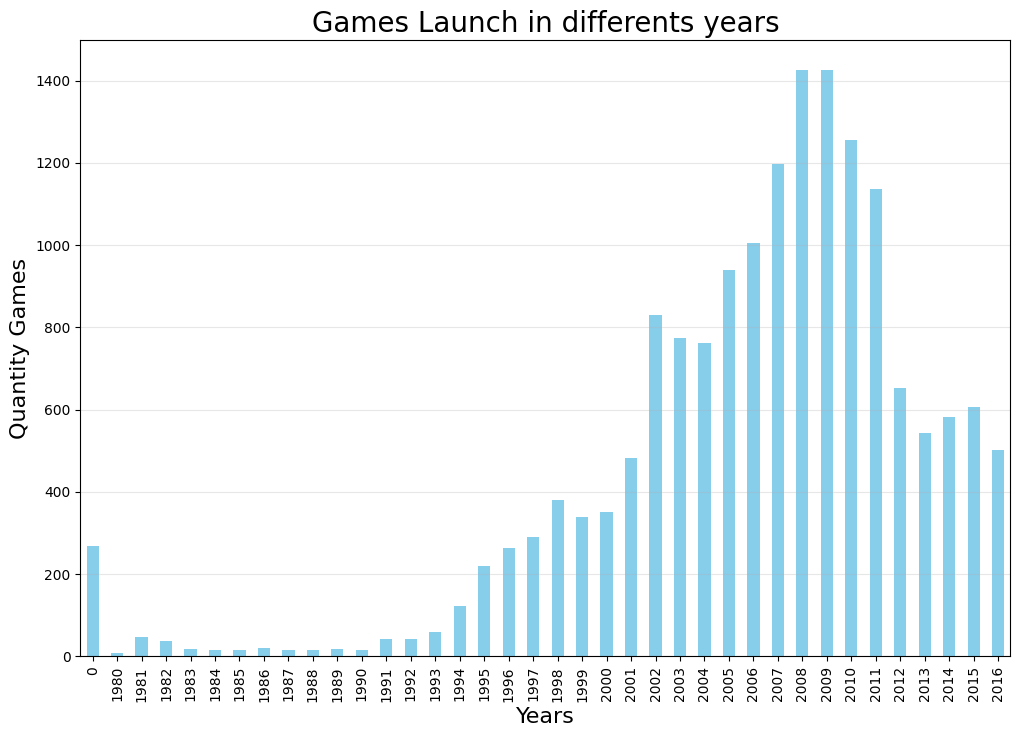

In [227]:
plt.figure(figsize=(12, 8))
games_launch_years.plot(kind='bar', color='skyblue')
plt.title('Games Launch in differents years', fontsize=20)
plt.xlabel('Years', fontsize=16)
plt.ylabel('Quantity Games', fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()

## General Conclusion for Games Lauch in different years.

The graph shows how the video game industry experienced sustained growth from the 1980s, reaching its peak between 2007 and 2009 with over 1,400 releases annually. 

This boom reflects market consolidation and platform expansion during that period. Subsequently, a decrease in the number of releases is observed, which can be attributed to changes in company strategy, a greater focus on quality over quantity, and the transition to new digital distribution models. Overall, the visualization allows us to understand the evolution of the sector and the factors that have shaped its dynamics over time.

In [228]:
clean_data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,0.0,RP,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,0.0,RP,31.38


In [229]:
platform_sales = clean_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

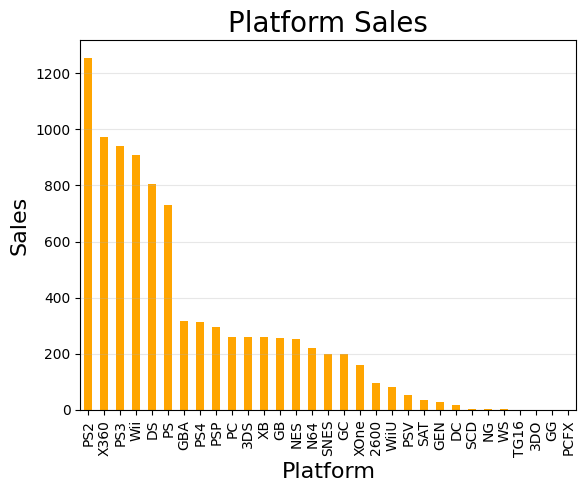

In [230]:
plt.Figure(figsize=(16, 10))
platform_sales.plot(kind='bar', color='orange')
plt.title('Platform Sales', fontsize=20)
plt.xlabel('Platform', fontsize=16)
plt.ylabel('Sales', fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Platform sales Conclusion

The chart clearly shows the PlayStation 2 (PS2) leading the way as the top-selling platform, solidifying its status as a historical benchmark in the gaming industry. It is followed by the Xbox 360 and PlayStation 3, reflecting the intense competition between Sony and Microsoft during that generation. The performance of consoles like the Wii and Nintendo DS demonstrates Nintendo's ability to capture different market segments with innovative offerings. In contrast, platforms like the PSP and PC show lower figures, suggesting a more limited market or one with different consumption patterns. Overall, the visualization allows us to identify how each console impacted the market and how each company's strategies influenced the distribution of global sales.

In [231]:
top10_platform = platform_sales.head(10).index.tolist()

In [232]:
clean_data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,0.0,RP,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,0.0,RP,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,0.0,RP,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,0.0,RP,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,0.0,RP,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,0.0,RP,0.01


In [233]:
clean_data[clean_data['platform'].isin(top10_platform)].groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

platform,DS,GBA,PC,PS,PS2,PS3,PS4,PSP,Wii,X360
year_of_release,,,,,,,,,,
0,3.34,4.97,3.76,3.28,22.21,8.31,0.00,4.52,16.33,10.18
1985,0.02,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1992,0.00,0.00,3.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1994,0.00,0.00,12.87,6.03,0.00,0.00,0.00,0.00,0.00,0.00
1995,0.00,0.00,4.22,35.96,0.00,0.00,0.00,0.00,0.00,0.00
1996,0.00,0.00,10.58,94.70,0.00,0.00,0.00,0.00,0.00,0.00
1997,0.00,0.00,11.27,136.17,0.00,0.00,0.00,0.00,0.00,0.00
1998,0.00,0.00,3.26,169.49,0.00,0.00,0.00,0.00,0.00,0.00


# Determinate data to take desicions on model 2017

The data should be taken from the most recent and representative period, that is, the years 2006 to 2016

Technical Justification:
* This range includes the most current platforms (PS3, PS4, X360, Wii, etc.), whose trends are relevant for projecting market behavior in 2017.
* Years prior to 2006 reflect generations of now-obsolete consoles (PS2, GBA, original DS), so their dynamics do not provide useful information for predicting future sales.
* The 2006–2016 period captures both the rise and decline of various platforms, allowing the model to learn patterns of growth and technological replacement.

# Conclusion: Use the data from 2006 to 2016 to train your sales or release prediction model for 2017, ensuring that the variables reflect the most recent market conditions and the evolution of modern consoles.

In [234]:
# DATA 2006 - 2016
data2006_2016 = clean_data[clean_data['year_of_release'] >= 2006] 
data2006_2016.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91


In [235]:
platform_sales2006_2016 = data2006_2016.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales2006_2016

platform
X360    952.99
PS3     931.33
Wii     891.18
DS      655.35
PS4     314.14
PS2     265.80
3DS     257.81
PSP     238.63
PC      163.42
XOne    159.32
WiiU     82.19
PSV      53.81
GC       11.53
XB       10.77
GBA       8.68
DC        0.06
Name: total_sales, dtype: float64

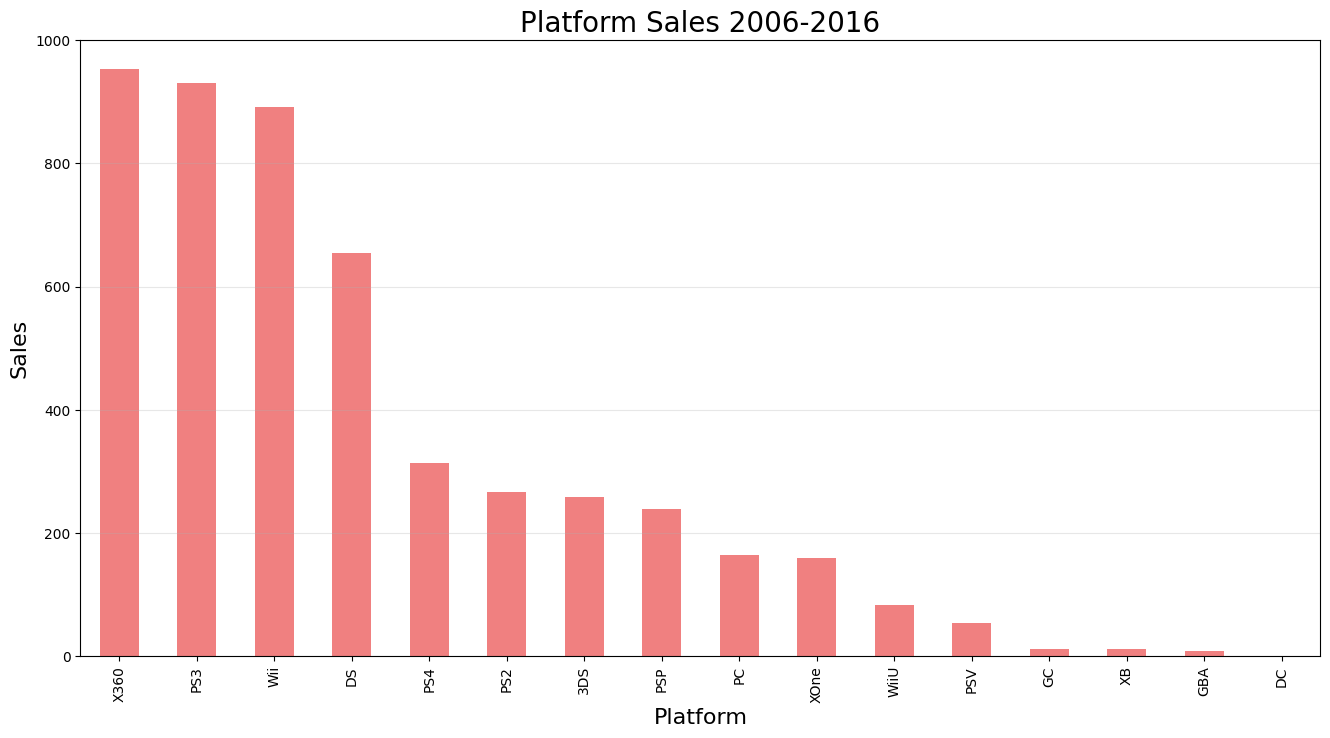

In [236]:
plt.figure(figsize=(16,8))
platform_sales2006_2016.plot(kind='bar', color='lightcoral')
plt.title('Platform Sales 2006-2016', fontsize=20)
plt.xlabel('Platform', fontsize=16)
plt.ylabel('Sales', fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()

* Xbox 360 (952.99), PlayStation 3 (931.33) and Wii (891.18) : These three consoles dominate the market, reflecting the intense competition of the 2006–2016 generation.

* Platforms with Growth
PlayStation 4 (314.14): Although with lower cumulative sales than its predecessors, it shows an upward trend due to being more recent.

Nintendo 3DS (257.81): Good performance in the handheld segment, with sustained growth.

Xbox One (159.32): Expanding, although still far from the historical leaders.

* Platforms in Decline or with Less Impact
PS2 (265.80) and PSP (238.63): Consoles that were very successful but are now declining.

Wii U (82.19) and PS Vita (53.81): Low performance, with difficulties in consolidating their position.

GameCube, Original Xbox, Dreamcast: Marginal sales, currently irrelevant.

* Potentially Profitable Platforms
PS4 and Xbox One: Modern consoles with room to grow.

3DS and DS: Handheld segment with good acceptance.

PC (163.42): Although smaller in volume, it maintains stability and relevance due to its open ecosystem.

# Strategic Conclusion:
The market shows a clear generational replacement cycle: older consoles are losing relevance while newer ones (PS4, XOne, 3DS) concentrate the growth potential. For a predictive model towards 2017, it is advisable to focus on these emerging platforms and on the stability of the PC as a complementary market.

In [237]:
platform_sales2006_2016

platform
X360    952.99
PS3     931.33
Wii     891.18
DS      655.35
PS4     314.14
PS2     265.80
3DS     257.81
PSP     238.63
PC      163.42
XOne    159.32
WiiU     82.19
PSV      53.81
GC       11.53
XB       10.77
GBA       8.68
DC        0.06
Name: total_sales, dtype: float64

In [238]:
top5_platform = platform_sales2006_2016.head(5).index.tolist()
data_top = data2006_2016[data2006_2016['platform'].isin(top5_platform)]

<Figure size 1500x800 with 0 Axes>

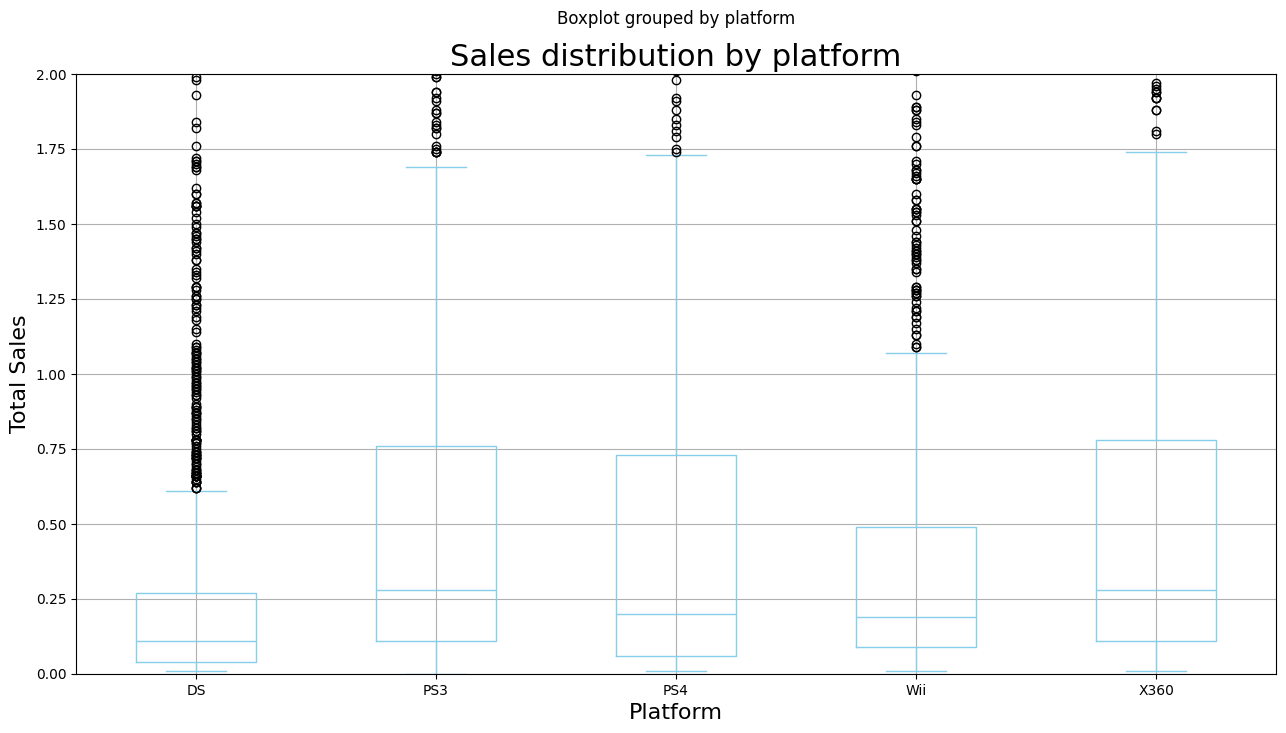

In [239]:
#  boxplot
plt.figure(figsize=(15, 8))
data_top.boxplot(column='total_sales', by='platform', figsize=(15, 8), color='skyblue')
plt.title('Sales distribution by platform', fontsize=22)
plt.xlabel('Platform', fontsize=16)
plt.ylabel('Total Sales', fontsize=16)
plt.ylim(0, 2)
plt.show()

Differences Between Platforms (Boxplot)

* The differences are significant: each platform shows a distinct distribution in the median and dispersion of sales.

1. PS3 and Xbox 360: These platforms have relatively high medians and a large number of outliers, indicating that some games had sales well above average.

2. Wii and DS: These platforms show lower medians, but with a wide dispersion, reflecting that although most games sold less, there were very successful titles that raised the extreme values.

3. PS4: Being more recent, its distribution is more concentrated, with less dispersion and fewer outliers, suggesting a market still consolidating.

 📈 Average Sales
* Median sales vary by platform:

1. Xbox 360 and PS3 tend to have higher average sales.

2. Wii and DS have lower medians, but with notable success stories.

3. PS4 shows an intermediate average, with less variability.

This implies that the previous generation consoles (PS3, X360) had a larger and more consistent market, while the newer ones (PS4) have not yet reached the same level of dispersion.

In conclusion, the analysis suggests that the more mature platforms (PS3, X360) offered more fertile ground for consistent sales, while the more recent ones (PS4) are still in an expansion phase, with growth potential but less historical dispersion.

In [240]:
data_top

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
...,...,...,...,...,...,...,...,...,...,...,...,...
16698,Mega Brain Boost,DS,2008,Puzzle,0.01,0.00,0.00,0.00,48.0,0.0,E,0.01
16700,Mezase!! Tsuri Master DS,DS,2009,Sports,0.00,0.00,0.01,0.00,NaN,0.0,RP,0.01
16704,Plushees,DS,2008,Simulation,0.01,0.00,0.00,0.00,NaN,0.0,E,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,0.0,RP,0.01


In [241]:
# Correlation between PS4 reviews and sales
data_ps4 = data_top[data_top['platform'] == 'PS4'].copy()

In [242]:
#drop files without reviews
ps4_with_reviews = data_ps4.dropna(subset=['critic_score', 'user_score'])

print(f"PS4 games with full reviews: {len(ps4_with_reviews)}")
print(f"Total PS4 games:: {len(data_ps4)}")

PS4 games with full reviews: 252
Total PS4 games:: 392


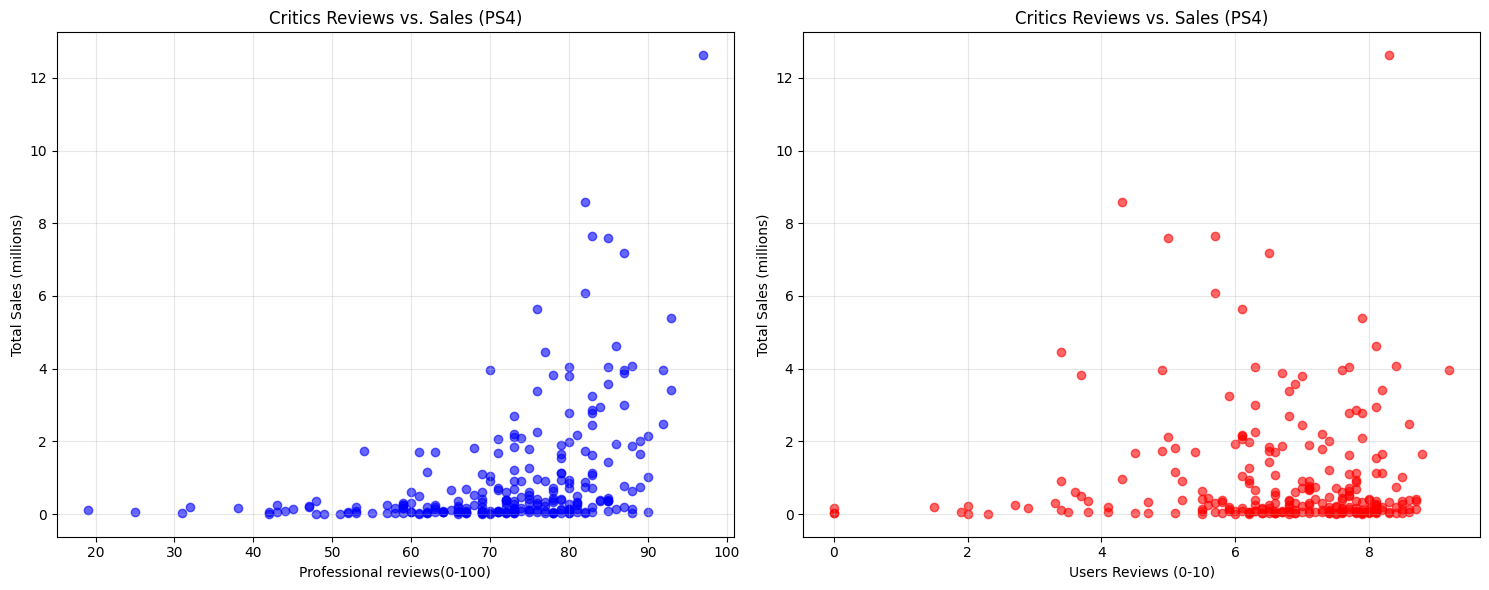

In [243]:
# Crear subplots para comparar ambas reseñas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Critic Score vs Ventas
ax1.scatter(ps4_with_reviews['critic_score'], ps4_with_reviews['total_sales'], 
           alpha=0.6, color='blue')
ax1.set_xlabel('Professional reviews(0-100)')
ax1.set_ylabel('Total Sales (millions)')
ax1.set_title('Critics Reviews vs. Sales (PS4)')
ax1.grid(True, alpha=0.3)

# Gráfico 2: User Score vs Ventas
ax2.scatter(ps4_with_reviews['user_score'], ps4_with_reviews['total_sales'], 
           alpha=0.6, color='red')
ax2.set_xlabel('Users Reviews (0-10)')
ax2.set_ylabel('Total Sales (millions)')
ax2.set_title('Critics Reviews vs. Sales (PS4)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* Critic Reviews: A stronger positive correlation exists. Games with higher professional ratings tend to sell more, although with some variation. This suggests that expert opinion significantly influences purchasing decisions.

* User Reviews: The correlation with sales is much weaker. While some titles with good user scores achieve high sales, a consistent pattern is not generally observed.

* Conclusion: Professional reviews have a greater impact on the commercial performance of PS4 games, while user reviews reflect individual perceptions more than a direct impact on sales.

In [244]:
clean_data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,0.0,RP,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,0.0,RP,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,0.0,RP,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,0.0,RP,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,0.0,RP,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,0.0,RP,0.01


In [245]:
# Count distribution Genre and videogames 
games_by_genre = clean_data.groupby('genre')['name'].count().sort_values(ascending=False)
games_by_genre

genre
Action          3369
Sports          2347
Misc            1750
Role-Playing    1498
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       873
Fighting         849
Strategy         683
Puzzle           580
Name: name, dtype: int64

In [246]:
# Total Sales by Genre
total_sales_by_genre = clean_data.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
total_sales_by_genre

genre
Action          1744.17
Sports          1331.26
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Name: total_sales, dtype: float64

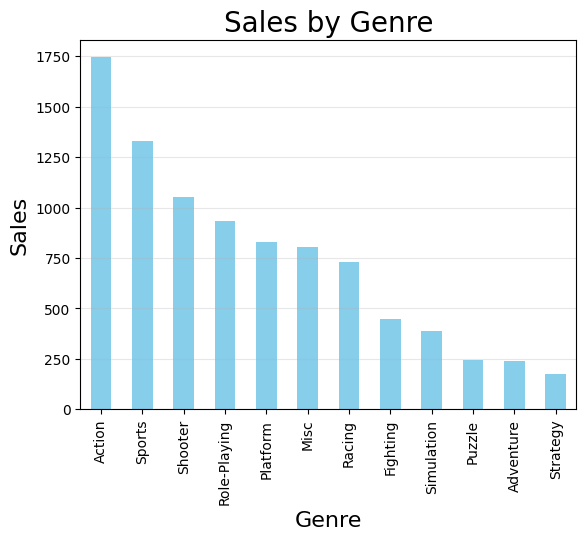

In [247]:
plt.Figure(figsize=(16, 8))
total_sales_by_genre.plot(kind='bar', color='skyblue')
plt.title('Sales by Genre', fontsize=20)
plt.xlabel('Genre', fontsize=16)
plt.ylabel('Sales', fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()

# conclusion: 

* The Action, Sports, and Shooter genres account for the majority of sales and are the most profitable, while genres such as Strategy, Puzzle, and Adventure show limited reach. This suggests that, for a predictive model or market strategy, it is advisable to prioritize leading genres while still considering that smaller genres can be valuable in specific niches.

In [248]:
# Total Sales by Region

top5_na = clean_data.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top5_eu = clean_data.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top5_jp = clean_data.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

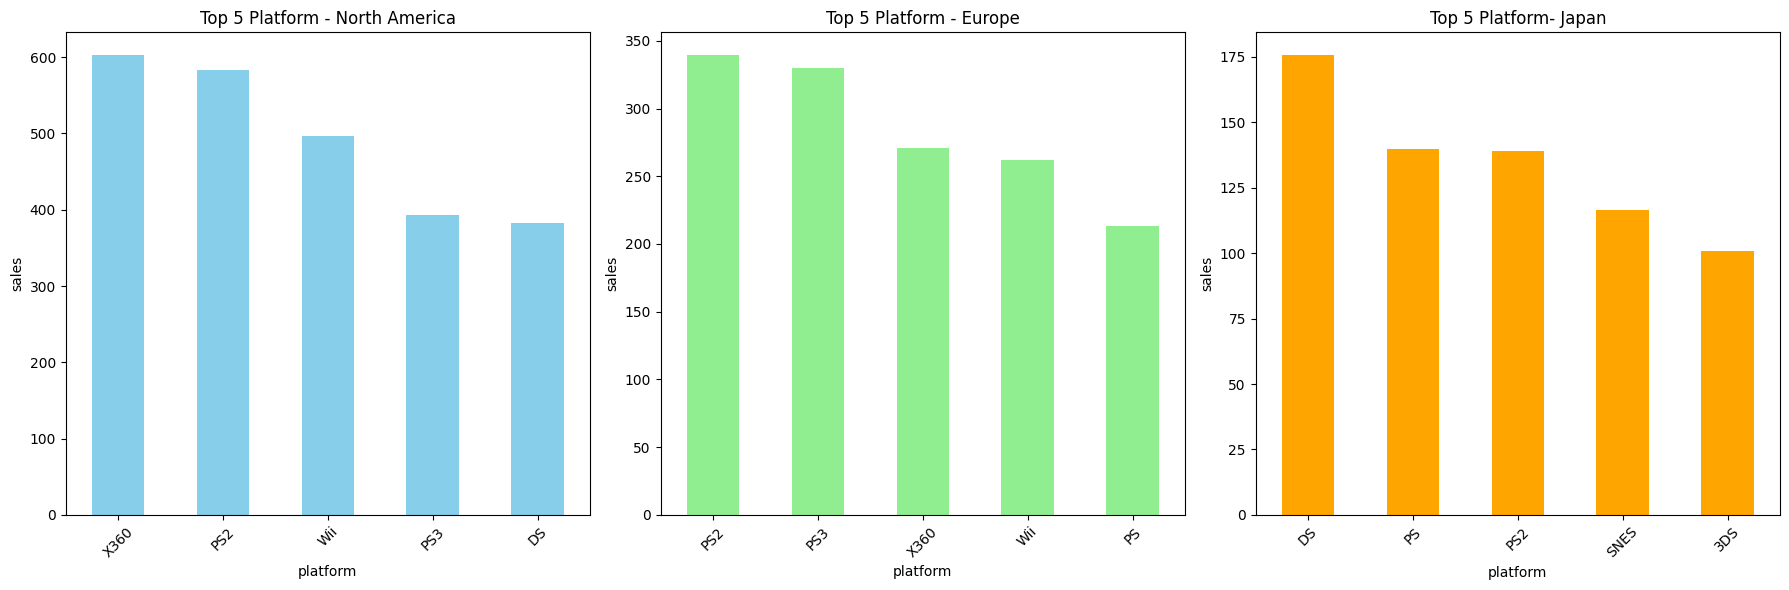

In [249]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Graph NORTH AMERICA
top5_na.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Top 5 Platform - North America')
ax1.set_ylabel('sales')
ax1.tick_params(axis='x', rotation=45)

# Graph EUROPE
top5_eu.plot(kind='bar', ax=ax2, color='lightgreen')
ax2.set_title('Top 5 Platform - Europe')
ax2.set_ylabel('sales')
ax2.tick_params(axis='x', rotation=45)

# Graph JAPAN
top5_jp.plot(kind='bar', ax=ax3, color='orange')
ax3.set_title('Top 5 Platform- Japan')
ax3.set_ylabel('sales')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [250]:
# sales by rating in each region
sales_rating_na = clean_data.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
sales_rating_eu = clean_data.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
sales_rating_jp = clean_data.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

<Figure size 1200x800 with 0 Axes>

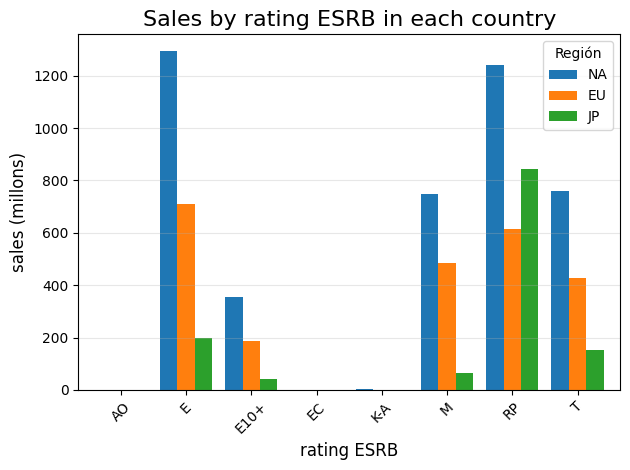

In [251]:
ratings_data = pd.DataFrame({
    'NA': sales_rating_na,
    'EU': sales_rating_eu, 
    'JP': sales_rating_jp
})

# Gráfico de barras agrupadas
plt.figure(figsize=(12, 8))
ratings_data.plot(kind='bar', width=0.8)
plt.title('Sales by rating ESRB in each country', fontsize=16)
plt.xlabel('rating ESRB', fontsize=12)
plt.ylabel('sales (millons)', fontsize=12)
plt.legend(title='Región')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

* Market Share Variations by Region
1. North America: Xbox 360 leads, followed by PS2, Wii, and PS3. This reflects Microsoft's strong market penetration.

2. Europe: PS2 and PS3 dominate, with Xbox 360 and Wii in secondary positions. Sony maintains a historical advantage in the region.

3. Japan: Nintendo DS leads, followed by PS2 and PS3. Nintendo has a stronger cultural presence and local preference.

 Conclusion: Each market has a different leader. Microsoft dominates in North America, Sony in Europe, and Nintendo in Japan, highlighting cultural and strategic differences within the industry.

* Impact by Region
1. North America (NA): This region boasts the highest sales across nearly all ratings.
- Games rated E (Everyone) and RP (Rating Pending) stand out, reflecting a broad, family-oriented market.
- There is also a strong presence of M (Mature) titles, demonstrating that the adult audience is a significant segment.

2. Europe (EU): This region maintains a similar pattern to North America, although with lower figures.
- E and M games account for the majority of sales, indicating a balance between family and adult titles.

3. Japan (JP): Sales are lower compared to NA and EU.
- A preference for E and T (Teen) games is observed, suggesting a market more geared towards young and family audiences.
- M titles have lower penetration than in the West.

* Conclusion
- ESRB ratings do influence regional sales:
- E and T are the most universal, with strong global acceptance.
- The M genre carries significant weight in the West, especially in North America.
- Japan shows less interest in games for adults, prioritizing family or youth-oriented experiences.

In [275]:
# Hypothesis Testing

# H0 = The average user ratings for the Xbox One and PC platforms are the same
# H1 = The average user ratings for the Xbox One and PC platforms are NOT the same.

xbox_one_scores = clean_data[clean_data['platform'] == 'XOne']['user_score'].dropna()
pc_scores = clean_data[clean_data['platform'] == 'PC']['user_score'].dropna()


# Significance level
alpha = 0.05

# T test value
results = stats.ttest_ind(xbox_one_scores, pc_scores)
print('P Value:', results.pvalue)

if (results.pvalue < alpha):
    print('We reject the null hypothesis')
else:
    print('We accept the null hypothesis')



P Value: 0.0005833414469972193
We reject the null hypothesis


# In the hypothesis test, the result indicates that the p-value was less than the significance level (α = 0.05).

conclusion: The null hypothesis (H0) is rejected, meaning there is statistically significant evidence to suggest that average user ratings on Xbox One and PC are different.

In other words, the data suggests that users rate games differently on each platform, and this difference cannot be attributed to chance.

In [276]:
# Hypothesis Testing

# H0 = The average user ratings for the Action and Sports genres are different
# H1 = The average user ratings for the Action and Sports genres are not different.

action_genres = clean_data[clean_data['genre'] == 'Action']['user_score'].dropna()
sports_genres= clean_data[clean_data['genre'] == 'Sports']['user_score'].dropna()


# Significance level
alpha = 0.05

# T test value
results = stats.ttest_ind(action_genres, sports_genres)
print('P Value:', results.pvalue)

if (results.pvalue < alpha):
    print('We reject the null hypothesis')
else:
    print('We accept the null hypothesis')

P Value: 1.1356758476860633e-08
We reject the null hypothesis


* conclusion of the hypothesis test results: 

The p-value obtained was much lower than the significance level (α = 0.05), therefore the null hypothesis is rejected. This means that there is statistically significant evidence to support the claim that the average ratings for the Action and Sports genres are different.

In other words, users rate action games differently from sports games, and this difference cannot be attributed to chance.

## General Conclusions:

1.The analysis, set in a simulated December 2016 scenario to project sales for 2017, provides practical value by demonstrating how to work with real data and extract insights applicable to any period.

2. The industry showed sustained growth since the 1980s, reaching its peak between 2007 and 2009, followed by a decline attributed to strategic changes and the transition to digital distribution.

3. The PlayStation 2 established itself as the best-selling console, while the Xbox 360 and PS3 reflected the intense competition of their generation. Nintendo, with the Wii and DS, captured distinct segments with innovative offerings.

4. To build a predictive model for 2017, the 2006–2016 period is the most representative, as it includes both the rise and fall of modern platforms, allowing for the identification of technological replacement patterns.

5. The PS4, Xbox One, and 3DS consoles, along with the stability of the PC market, represent the potential for future growth, while platforms like the PS2, PSP, and Wii U are showing decline.

6. In terms of genres, Action, Sports, and Shooter games account for the majority of sales and are the most profitable, while genres like Strategy, Puzzle, and Adventure have less reach, although they are useful in specific niches.

  For a predictive model toward 2017, it is advisable to focus on emerging platforms (PS4, Xbox One, 3DS, PC) and the most profitable genres, ensuring that the variables reflect the most recent conditions and the evolution of the sector.

In [ ]:
## General Conclusions